<a href="https://colab.research.google.com/github/donw385/Big-Data-Bowl/blob/master/Don_Wang_NFL_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Preparation**

In [0]:
#imports 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import altair as alt
import itertools
import re
import plotly.plotly as py
import plotly.tools as tls
from vega_datasets import data
pd.options.display.max_columns = 500



In [1]:
#upgrade seaborn
!pip install --upgrade seaborn


Requirement already up-to-date: seaborn in /usr/local/lib/python3.6/dist-packages (0.9.0)


In [2]:
#read data, can't do tracking merge, crashes the server

games = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/games.csv')
players = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/players.csv')
plays = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/plays.csv')
tracking = pd.read_csv('https://raw.githubusercontent.com/nfl-football-ops/Big-Data-Bowl/master/Data/tracking_gameId_2017090700.csv')
# tracking1 = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/tracking_gameId_2017091000.csv')
# tracking2 = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/tracking_gameId_2017091001.csv')
# tracking3 = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/tracking_gameId_2017091002.csv')
# tracking4 = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/tracking_gameId_2017091003.csv')
# tracking5 = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/tracking_gameId_2017091004.csv')
# tracking6 = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/tracking_gameId_2017091005.csv')
# tracking7 = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/tracking_gameId_2017091007.csv')

NameError: ignored

In [1]:
# merged_tracking = pd.merge(plays, tracking, how='inner', on='playId')
# merged_tracking = pd.merge(merged_tracking, tracking1, how='inner', on='playId')
# merged_tracking = pd.merge(merged_tracking, tracking2, how='inner', on='playId')
# merged_tracking = pd.merge(merged_tracking, tracking3, how='inner', on='playId')
# merged_tracking = pd.merge(merged_tracking, tracking4, how='inner', on='playId')
# merged_tracking = pd.merge(merged_tracking, tracking5, how='inner', on='playId')
# merged_tracking = pd.merge(merged_tracking, tracking6, how='inner', on='playId')
# merged_tracking = pd.merge(merged_tracking, tracking7, how='inner', on='playId')



NameError: ignored

**Initial Data Analysis**

In [5]:
games.shape, players.shape, plays.shape, tracking.shape

((91, 21), (1713, 10), (14193, 27), (316025, 14))

In [6]:
games.columns

Index(['season', 'week', 'gameDate', 'gameId', 'gameTimeEastern', 'HomeScore',
       'VisitorScore', 'homeTeamAbbr', 'visitorTeamAbbr', 'homeDisplayName',
       'visitorDisplayName', 'Stadium', 'Location', 'StadiumType', 'Turf',
       'GameLength', 'GameWeather', 'Temperature', 'Humidity', 'WindSpeed',
       'WindDirection'],
      dtype='object')

In [61]:
plays.columns

Index(['gameId', 'playId', 'quarter', 'GameClock', 'down', 'yardsToGo',
       'possessionTeam', 'yardlineSide', 'yardlineNumber', 'offenseFormation',
       'personnel.offense', 'defendersInTheBox', 'numberOfPassRushers',
       'personnel.defense', 'HomeScoreBeforePlay', 'VisitorScoreBeforePlay',
       'HomeScoreAfterPlay', 'VisitorScoreAfterPlay', 'isPenalty', 'isSTPlay',
       'SpecialTeamsPlayType', 'KickReturnYardage', 'PassLength', 'PassResult',
       'YardsAfterCatch', 'PlayResult', 'playDescription'],
      dtype='object')

In [62]:
tracking.columns

Index(['time', 'x', 'y', 's', 'dis', 'dir', 'event', 'nflId', 'displayName',
       'jerseyNumber', 'team', 'frame.id', 'gameId', 'playId'],
      dtype='object')

In [7]:
players.head()

,nflId,FirstName,LastName,PositionAbbr,EntryYear,DraftRound,DraftNumber,Height,Weight,College
0,79860,John,Stafford,QB,2009,1.0,1.0,"6'03""",220,Georgia
1,71465,Andre,Smith,T,2009,1.0,6.0,"6'04""",325,Alabama
2,80427,Darrius,Heyward-Bey,WR,2009,1.0,7.0,"6'02""",210,Maryland
3,71269,Michael,Crabtree,WR,2009,1.0,10.0,"6'01""",214,Texas Tech
4,71423,Brian,Orakpo,OLB,2009,1.0,13.0,"6'04""",257,Texas


In [0]:
def decimalize_feet(s):
    m = re.match(r'^(\d+)\'(\d+)\"$', s)
    if m:
        return float(m.group(1)) + float(m.group(2)) / 12.
    else:
        return None
  
players['Height'] = players['Height'].apply(lambda x:decimalize_feet(x))


In [9]:
players.head(500)

,nflId,FirstName,LastName,PositionAbbr,EntryYear,DraftRound,DraftNumber,Height,Weight,College
0,79860,John,Stafford,QB,2009,1.0,1.0,6.250000,220,Georgia
1,71465,Andre,Smith,T,2009,1.0,6.0,6.333333,325,Alabama
2,80427,Darrius,Heyward-Bey,WR,2009,1.0,7.0,6.166667,210,Maryland
3,71269,Michael,Crabtree,WR,2009,1.0,10.0,6.083333,214,Texas Tech
4,71423,Brian,Orakpo,OLB,2009,1.0,13.0,6.333333,257,Texas
5,79848,Malcolm,Jenkins,SS,2009,1.0,14.0,6.000000,204,Ohio State
6,80421,Brian,Cushing,ILB,2009,1.0,15.0,6.250000,255,Southern California
7,71193,Robert,Ayers,DE,2009,1.0,18.0,6.250000,275,Tennessee
8,80429,Jeremy,Maclin,WR,2009,1.0,19.0,6.000000,198,Missouri
9,71375,Alex,Mack,C,2009,1.0,21.0,6.333333,311,California


In [0]:
players['All_Draft_Round'] = players['DraftRound'].fillna('Undrafted')


In [11]:
players.shape

(1713, 11)

In [12]:
players.describe()

,nflId,EntryYear,DraftRound,DraftNumber,Height,Weight
count,1.713000e+03,1713.000000,1185.000000,1185.000000,1712.000000,1713.000000
mean,2.358148e+06,2013.375949,3.413502,99.707173,6.164622,244.998249
std,6.251065e+05,3.171858,1.924983,70.428223,0.219778,45.796271
min,2.340000e+02,1996.000000,1.000000,1.000000,5.500000,158.000000
25%,2.532873e+06,2012.000000,2.000000,38.000000,6.000000,205.000000
50%,2.543860e+06,2014.000000,3.000000,88.000000,6.166667,236.000000
75%,2.555343e+06,2016.000000,5.000000,157.000000,6.333333,287.000000
max,2.559368e+06,2017.000000,7.000000,256.000000,6.750000,355.000000


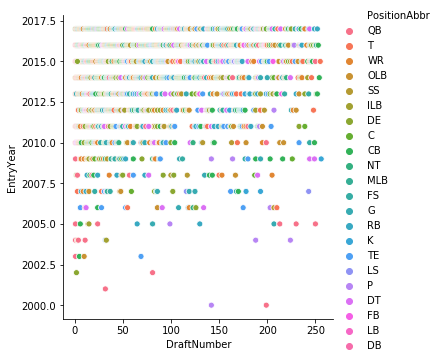

In [13]:
sns.relplot(x='DraftNumber', y='EntryYear', hue='PositionAbbr', data=players);


In [14]:
player_summary = pd.crosstab(players['All_Draft_Round'],players['PositionAbbr'], margins=True)
player_summary


PositionAbbr,C,CB,DB,DE,DT,FB,FS,G,ILB,K,LB,LS,MLB,NT,OLB,P,QB,RB,SS,T,TE,WR,All
All_Draft_Round,,,,,,,,,,,,,,,,,,,,,,,
1.0,6,35,1,26,19,0,10,13,9,0,0,0,4,3,23,0,20,11,6,28,10,33,257
2.0,10,18,0,22,11,0,13,11,8,0,0,0,8,3,18,0,6,12,10,14,14,24,202
3.0,6,20,0,21,16,0,7,21,3,0,0,0,3,4,14,2,7,17,7,7,15,28,198
4.0,5,14,0,15,10,2,7,13,6,1,0,1,4,5,12,0,3,16,10,7,11,17,159
5.0,4,20,0,6,10,2,4,8,8,3,0,1,5,2,13,5,3,13,7,10,12,14,150
6.0,7,12,0,7,11,5,8,6,3,5,0,0,1,0,11,6,5,11,5,5,10,11,129
7.0,5,12,0,6,4,1,7,2,4,3,1,1,3,1,6,3,3,5,1,9,4,9,90
Undrafted,12,49,2,27,26,15,23,32,23,24,3,31,10,9,42,17,3,35,27,27,33,58,528
All,55,180,3,130,107,25,79,106,64,36,4,34,38,27,139,33,50,120,73,107,109,194,1713


In [15]:
player_summary2 = ((pd.crosstab(players['All_Draft_Round'],players['PositionAbbr'], margins=True, normalize=True))*100).round(2)
player_summary2

PositionAbbr,C,CB,DB,DE,DT,FB,FS,G,ILB,K,LB,LS,MLB,NT,OLB,P,QB,RB,SS,T,TE,WR,All
All_Draft_Round,,,,,,,,,,,,,,,,,,,,,,,
1.0,0.35,2.04,0.06,1.52,1.11,0.00,0.58,0.76,0.53,0.00,0.00,0.00,0.23,0.18,1.34,0.00,1.17,0.64,0.35,1.63,0.58,1.93,15.00
2.0,0.58,1.05,0.00,1.28,0.64,0.00,0.76,0.64,0.47,0.00,0.00,0.00,0.47,0.18,1.05,0.00,0.35,0.70,0.58,0.82,0.82,1.40,11.79
3.0,0.35,1.17,0.00,1.23,0.93,0.00,0.41,1.23,0.18,0.00,0.00,0.00,0.18,0.23,0.82,0.12,0.41,0.99,0.41,0.41,0.88,1.63,11.56
4.0,0.29,0.82,0.00,0.88,0.58,0.12,0.41,0.76,0.35,0.06,0.00,0.06,0.23,0.29,0.70,0.00,0.18,0.93,0.58,0.41,0.64,0.99,9.28
5.0,0.23,1.17,0.00,0.35,0.58,0.12,0.23,0.47,0.47,0.18,0.00,0.06,0.29,0.12,0.76,0.29,0.18,0.76,0.41,0.58,0.70,0.82,8.76
6.0,0.41,0.70,0.00,0.41,0.64,0.29,0.47,0.35,0.18,0.29,0.00,0.00,0.06,0.00,0.64,0.35,0.29,0.64,0.29,0.29,0.58,0.64,7.53
7.0,0.29,0.70,0.00,0.35,0.23,0.06,0.41,0.12,0.23,0.18,0.06,0.06,0.18,0.06,0.35,0.18,0.18,0.29,0.06,0.53,0.23,0.53,5.25
Undrafted,0.70,2.86,0.12,1.58,1.52,0.88,1.34,1.87,1.34,1.40,0.18,1.81,0.58,0.53,2.45,0.99,0.18,2.04,1.58,1.58,1.93,3.39,30.82
All,3.21,10.51,0.18,7.59,6.25,1.46,4.61,6.19,3.74,2.10,0.23,1.98,2.22,1.58,8.11,1.93,2.92,7.01,4.26,6.25,6.36,11.33,100.00


In [16]:
player_summary_year = pd.crosstab(players['EntryYear'],players['PositionAbbr'], margins=True)
player_summary_year


PositionAbbr,C,CB,DB,DE,DT,FB,FS,G,ILB,K,LB,LS,MLB,NT,OLB,P,QB,RB,SS,T,TE,WR,All
EntryYear,,,,,,,,,,,,,,,,,,,,,,,
1996,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
1998,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
2000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,2
2001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
2002,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,4
2003,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,2,0,5
2004,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,2,3,0,1,1,1,1,11
2005,0,1,0,1,0,1,0,2,1,2,0,3,0,0,2,1,5,2,0,0,0,0,21
2006,0,3,0,1,4,0,0,1,0,2,0,0,0,1,1,2,1,0,1,3,4,1,25


In [17]:
player_positions = pd.DataFrame(players['PositionAbbr'].value_counts())
player_positions = player_positions.reset_index()
player_positions


,index,PositionAbbr
0,WR,194
1,CB,180
2,OLB,139
3,DE,130
4,RB,120
5,TE,109
6,DT,107
7,T,107
8,G,106
9,FS,79


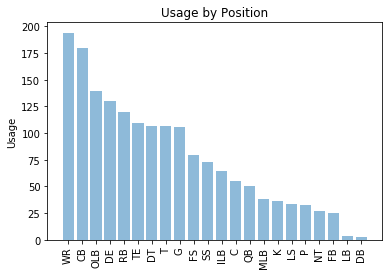

In [18]:
objects = player_positions['index']
y_pos = np.arange(len(objects))
performance = player_positions['PositionAbbr']
 
plt.bar(y_pos, performance, align='center', alpha=0.5)
plt.xticks(y_pos, objects)
plt.ylabel('Usage')
plt.title('Usage by Position')
plt.xticks(rotation='vertical')

 
plt.show()

In [19]:
player_summary_year2 = ((pd.crosstab(players['EntryYear'],players['PositionAbbr'], margins=True, normalize=True))*100).round(2)
player_summary_year2

PositionAbbr,C,CB,DB,DE,DT,FB,FS,G,ILB,K,LB,LS,MLB,NT,OLB,P,QB,RB,SS,T,TE,WR,All
EntryYear,,,,,,,,,,,,,,,,,,,,,,,
1996,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06
1998,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06
2000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06,0.06,0.00,0.00,0.00,0.00,0.00,0.12
2001,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.06
2002,0.00,0.00,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.06,0.00,0.00,0.00,0.00,0.06,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.23
2003,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06,0.00,0.06,0.00,0.00,0.00,0.12,0.00,0.29
2004,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06,0.00,0.00,0.06,0.00,0.00,0.00,0.12,0.18,0.00,0.06,0.06,0.06,0.06,0.64
2005,0.00,0.06,0.00,0.06,0.00,0.06,0.00,0.12,0.06,0.12,0.00,0.18,0.00,0.00,0.12,0.06,0.29,0.12,0.00,0.00,0.00,0.00,1.23
2006,0.00,0.18,0.00,0.06,0.23,0.00,0.00,0.06,0.00,0.12,0.00,0.00,0.00,0.06,0.06,0.12,0.06,0.00,0.06,0.18,0.23,0.06,1.46


In [20]:
players[(players.EntryYear<2003)]

,nflId,FirstName,LastName,PositionAbbr,EntryYear,DraftRound,DraftNumber,Height,Weight,College,All_Draft_Round
29,2503471,Adam,Vinatieri,K,1996,NaN,NaN,6.000000,212,South Dakota State,Undrafted
30,2500351,Philip,Dawson,K,1998,NaN,NaN,5.916667,200,Texas,Undrafted
31,2505076,Joshua,McCown,QB,2002,3.0,81.0,6.333333,218,Sam Houston State,3
32,2504797,Steven,Bryant,K,2002,NaN,NaN,5.750000,203,Baylor,Undrafted
33,2505010,Julius,Peppers,DE,2002,1.0,2.0,6.583333,295,North Carolina,1
34,2504844,James,Harrison,OLB,2002,NaN,NaN,6.000000,242,Kent State,Undrafted
430,2504319,Edward,Lechler,P,2000,5.0,142.0,6.166667,230,Texas A&M,5
431,2504211,Tom,Brady,QB,2000,6.0,199.0,NaN,225,Michigan,6
432,2504775,Drew,Brees,QB,2001,2.0,32.0,6.000000,209,Purdue,2


In [21]:
players.columns

Index(['nflId', 'FirstName', 'LastName', 'PositionAbbr', 'EntryYear',
       'DraftRound', 'DraftNumber', 'Height', 'Weight', 'College',
       'All_Draft_Round'],
      dtype='object')

In [22]:
players.shape

(1713, 11)

**College Analysis**

In [23]:
colleges = players['College'].value_counts()
top_20=colleges.head(20)
top_20.describe()

count    20.000000
mean     29.750000
std       5.149093
min      23.000000
25%      25.750000
50%      28.000000
75%      34.250000
max      39.000000
Name: College, dtype: float64

In [0]:
college_list = top_20.index.values.tolist()


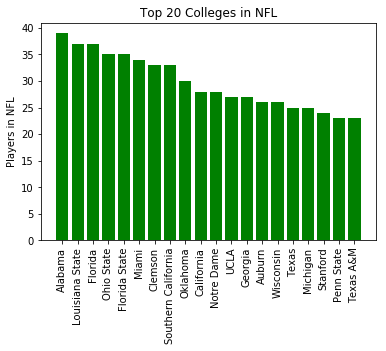

In [25]:
plt.bar(college_list,top_20, label="Example two", color='g')
plt.xticks(rotation='vertical')
plt.ylabel('Players in NFL')

plt.title('Top 20 Colleges in NFL')

plt.show()


In [26]:
position_summary = players.groupby('PositionAbbr').describe()
position_summary.head(25)



DraftNumber                                                       \
                   count        mean        std    min     25%    50%     75%   
PositionAbbr                                                                    
C                   43.0  114.651163  75.048202   15.0   55.50   93.0  189.00   
CB                 131.0   99.992366  72.980766    5.0   30.50   89.0  157.50   
DB                   1.0   24.000000        NaN   24.0   24.00   24.0   24.00   
DE                 103.0   82.737864  66.093214    1.0   31.50   69.0  119.00   
DT                  81.0   98.160494  70.384028    2.0   44.00   88.0  151.00   
FB                  10.0  174.500000  37.936350  108.0  144.00  186.5  204.00   
FS                  56.0  105.303571  74.967610   14.0   38.75   84.0  174.75   
G                   74.0   93.229730  59.259251    2.0   45.75   81.5  133.75   
ILB                 41.0  104.585366  74.413028    7.0   40.00  113.0  154.00   
K                   12.0  183.750000  37.863691  118.0  164.75  176.0  200.75   
LB                   1.0  232.000000        NaN  232.0  232.00  232.0  232.00   
LS                   3.0  175.000000  63.976558  116.0  141.00  166.0  204.50   
MLB                 28.0  102.142857  72.984886    9.0   38.00   87.5  162.00   
NT                  18.0   95.666667  54.785142   27.0   43.75   89.5  123.00   
OLB                 97.0   95.989691  69.079286    1.0   36.00   83.0  153.00   
P                   16.0  174.000000  45.410718   70.0  151.75  183.5  204.00   
QB                  47.0   75.085106  79.718480    1.0    3.00   52.0  135.00   
RB                  85.0  110.835294  64.440975    4.0   57.00  106.0  154.00   
SS                  46.0  100.130435  61.735136    5.0   51.75   99.0  143.50   
T                   80.0   89.025000  78.965138    1.0   20.75   63.0  153.50   
TE                  76.0  106.671053  63.478582    6.0   50.75   99.0  159.25   
WR                 136.0   90.985294  67.120564    3.0   33.75   80.5  141.25   

                    DraftRound                                                \
                max      count      mean       std  min  25%  50%   75%  max   
PositionAbbr                                                                   
C             251.0       43.0  3.744186  2.036489  1.0  2.0  3.0  6.00  7.0   
CB            254.0      131.0  3.381679  2.024686  1.0  1.0  3.0  5.00  7.0   
DB             24.0        1.0  1.000000       NaN  1.0  1.0  1.0  1.00  1.0   
DE            239.0      103.0  2.980583  1.782159  1.0  1.5  3.0  4.00  7.0   
DT            249.0       81.0  3.370370  1.900292  1.0  2.0  3.0  5.00  7.0   
FB            215.0       10.0  5.500000  0.971825  4.0  5.0  6.0  6.00  7.0   
FS            245.0       56.0  3.607143  2.086132  1.0  2.0  3.0  6.00  7.0   
G             243.0       74.0  3.243243  1.611694  1.0  2.0  3.0  4.00  7.0   
ILB           250.0       41.0  3.512195  2.013976  1.0  2.0  4.0  5.00  7.0   
K             256.0       12.0  5.833333  0.937437  4.0  5.0  6.0  6.25  7.0   
LB            232.0        1.0  7.000000       NaN  7.0  7.0  7.0  7.00  7.0   
LS            243.0        3.0  5.333333  1.527525  4.0  4.5  5.0  6.00  7.0   
MLB           251.0       28.0  3.464286  1.914509  1.0  2.0  3.0  5.00  7.0   
NT            220.0       18.0  3.222222  1.592466  1.0  2.0  3.0  4.00  7.0   
OLB           233.0       97.0  3.319588  1.934050  1.0  2.0  3.0  5.00  7.0   
P             235.0       16.0  5.500000  1.211060  3.0  5.0  6.0  6.00  7.0   
QB            250.0       47.0  2.787234  2.042336  1.0  1.0  2.0  4.00  7.0   
RB            252.0       85.0  3.717647  1.756700  1.0  2.0  4.0  5.00  7.0   
SS            244.0       46.0  3.456522  1.656053  1.0  2.0  3.5  5.00  7.0   
T             255.0       80.0  3.100000  2.138259  1.0  1.0  2.0  5.00  7.0   
TE            246.0       76.0  3.618421  1.781139  1.0  2.0  3.0  5.00  7.0   
WR            245.0      136.0  3.176471  1.861431  1.0  2.0  3.0  

**Height and Weight By Position Group** *italicized text*

In [0]:
height_and_weight = position_summary.loc[:, list(itertools.product(['Height','Weight'], ['50%']))]


In [0]:
height_and_weight=height_and_weight.reset_index()

In [0]:
height_and_weight['Height'] = height_and_weight['Height'].round(2)
height_and_weight['Weight'] = height_and_weight['Weight'].round(2)

In [30]:
height_and_weight

,PositionAbbr,Height,Weight
,,50%,50%
0,C,6.33,305.0
1,CB,6.00,195.0
2,DB,6.00,195.0
3,DE,6.33,272.5
4,DT,6.25,305.0
5,FB,6.08,240.0
6,FS,6.00,205.0
7,G,6.33,314.0
8,ILB,6.08,237.0


In [31]:
position_list = height_and_weight['PositionAbbr'].tolist()
position_list

['C',
 'CB',
 'DB',
 'DE',
 'DT',
 'FB',
 'FS',
 'G',
 'ILB',
 'K',
 'LB',
 'LS',
 'MLB',
 'NT',
 'OLB',
 'P',
 'QB',
 'RB',
 'SS',
 'T',
 'TE',
 'WR']

In [0]:
height_list = height_and_weight['Height'].values.tolist()


In [0]:
weight_list = height_and_weight['Weight'].values.tolist()
 

In [34]:
height = height_and_weight.Height
weight = height_and_weight.Weight

x = height_list
y = weight_list
types= position_list

xrange = [5, 7]
yrange = [150, 350]


source = pd.DataFrame({
    'x': height_list,
    'y': weight_list,
    'label': position_list
})

bars = alt.Chart(source).mark_point().encode(
    x=alt.X('x', axis=alt.Axis(title='Height in feet',grid=True)),
    y=alt.Y('y', axis=alt.Axis(title='Weight in pounds',grid=True))
)

text = bars.mark_text(
    align='left',
    baseline='middle',
    dx=7
).encode(
    text='label'
).interactive()


bars + text



LayerChart({
  layer: [Chart({
    data:    label       x        y
    0      C  [6.33]  [305.0]
    1     CB   [6.0]  [195.0]
    2     DB   [6.0]  [195.0]
    3     DE  [6.33]  [272.5]
    4     DT  [6.25]  [305.0]
    5     FB  [6.08]  [240.0]
    6     FS   [6.0]  [205.0]
    7      G  [6.33]  [314.0]
    8    ILB  [6.08]  [237.0]
    9      K   [6.0]  [197.5]
    10    LB  [6.17]  [228.5]
    11    LS  [6.21]  [243.5]
    12   MLB  [6.08]  [238.5]
    13    NT  [6.25]  [314.0]
    14   OLB  [6.25]  [245.0]
    15     P  [6.17]  [210.0]
    16    QB  [6.33]  [223.5]
    17    RB  [5.92]  [215.0]
    18    SS   [6.0]  [208.0]
    19     T   [6.5]  [315.0]
    20    TE  [6.42]  [255.0]
    21    WR  [6.08]  [202.0],
    encoding: EncodingWithFacet({
      x: X({
        axis: Axis({
          grid: True,
          title: 'Height in feet'
        }),
        shorthand: 'x'
      }),
      y: Y({
        axis: Axis({
          grid: True,
          title: 'Weight in pounds'
        }),
        shorthand: 'y'
      })
    }),
    mark: 'point'
  }), Chart({
    data:    label       x        y
    0      C  [6.33]  [305.0]
    1     CB   [6.0]  [195.0]
    2     DB   [6.0]  [195.0]
    3     DE  [6.33]  [272.5]
    4     DT  [6.25]  [305.0]
    5     FB  [6.08]  [240.0]
    6     FS   [6.0]  [205.0]
    7      G  [6.33]  [314.0]
    8    ILB  [6.08]  [237.0]
    9      K   [6.0]  [197.5]
    10    LB  [6.17]  [228.5]
    11    LS  [6.21]  [243.5]
    12   MLB  [6.08]  [238.5]
    13    NT  [6.25]  [314.0]
    14   OLB  [6.25]  [245.0]
    15     P  [6.17]  [210.0]
    16    QB  [6.33]  [223.5]
    17    RB  [5.92]  [215.0]
    18    SS   [6.0]  [208.0]
    19     T   [6.5]  [315.0]
    20    TE  [6.42]  [255.0]
    21    WR  [6.08]  [202.0],
    encoding: EncodingWithFacet({
      text: Text({
        shorthand: 'label'
      }),
      x: X({
        axis: Axis({
          grid: True,
          title: 'Height in feet'
        }),
        shorthand: 'x'
      }),
      y: Y({
        axis: Axis({
          grid: True,
          title: 'Weight in pounds'
        }),
        shorthand: 'y'
      })
    }),
    mark: MarkDef({
      align: 'left',
      baseline: 'middle',
      dx: 7,
      type: 'text'
    }),
    selection: SelectionMapping({
      selector001: SelectionDef({
        bind: 'scales',
        encodings: ['x', 'y'],
        type: 'interval'
      })
    })
  })]
})

**Draft Position and Entry Year by Position Group**

In [0]:
draft_and_year = position_summary.loc[:, list(itertools.product(['DraftNumber','EntryYear'], ['50%']))]


In [0]:
draft_and_year=draft_and_year.reset_index()

In [0]:
draft_and_year=draft_and_year.sort_values([('DraftNumber', '50%')], ascending=True)

In [0]:
draft_list = draft_and_year['DraftNumber'].values.tolist()
year_list = draft_and_year['EntryYear'].values.tolist()
position_list2 = draft_and_year['PositionAbbr'].tolist()


In [39]:
position_list2

['DB',
 'QB',
 'T',
 'DE',
 'WR',
 'G',
 'OLB',
 'FS',
 'MLB',
 'DT',
 'CB',
 'NT',
 'C',
 'TE',
 'SS',
 'RB',
 'ILB',
 'LS',
 'K',
 'P',
 'FB',
 'LB']

In [40]:
year_and_number = pd.DataFrame(np.column_stack([draft_list, year_list, position_list2]), 
                               columns=['Draft', 'Year', 'Position'])
year_and_number.head(25)

,Draft,Year,Position
0,24.0,2017.0,DB
1,52.0,2011.5,QB
2,63.0,2014.0,T
3,69.0,2014.0,DE
4,80.5,2014.0,WR
5,81.5,2014.0,G
6,83.0,2014.0,OLB
7,84.0,2014.0,FS
8,87.5,2015.0,MLB
9,88.0,2014.0,DT


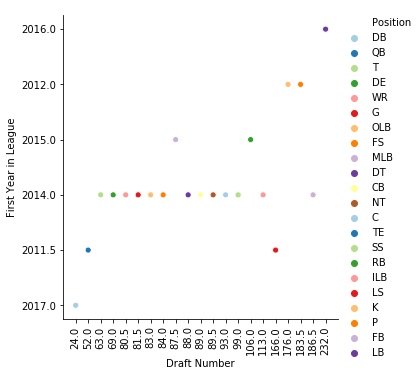

In [41]:
# source2 = pd.DataFrame({
#     'x': draft_list,
#     'y': year_list,
#     'label': position_list2
# })

# bars2 = alt.Chart(source2).mark_point().encode(
#     x=alt.X('x', axis=alt.Axis(title='Draft Number',grid=True)),
#     y=alt.Y('y', axis=alt.Axis(title='First Year in NFL',grid=True))
# )

# text2 = bars2.mark_text(
#     align='left',
#     baseline='middle',
#     dx=7
# ).encode(
#     text='label'
# )

# bars2 + text2

ax = sns.relplot(x='Draft', y='Year', hue='Position', palette='Paired',data=year_and_number)
ax.set_xticklabels(rotation=90)
plt.xlabel("Draft Number")
plt.ylabel("First Year in League");

In [42]:
position_summary.head()

DraftNumber                                                  \
                   count        mean        std   min   25%   50%    75%   
PositionAbbr                                                               
C                   43.0  114.651163  75.048202  15.0  55.5  93.0  189.0   
CB                 131.0   99.992366  72.980766   5.0  30.5  89.0  157.5   
DB                   1.0   24.000000        NaN  24.0  24.0  24.0   24.0   
DE                 103.0   82.737864  66.093214   1.0  31.5  69.0  119.0   
DT                  81.0   98.160494  70.384028   2.0  44.0  88.0  151.0   

                    DraftRound                                               \
                max      count      mean       std  min  25%  50%  75%  max   
PositionAbbr                                                                  
C             251.0       43.0  3.744186  2.036489  1.0  2.0  3.0  6.0  7.0   
CB            254.0      131.0  3.381679  2.024686  1.0  1.0  3.0  5.0  7.0   
DB             24.0        1.0  1.000000       NaN  1.0  1.0  1.0  1.0  1.0   
DE            239.0      103.0  2.980583  1.782159  1.0  1.5  3.0  4.0  7.0   
DT            249.0       81.0  3.370370  1.900292  1.0  2.0  3.0  5.0  7.0   

             EntryYear                                                         \
                 count         mean       std     min     25%     50%     75%   
PositionAbbr                                                                    
C                 55.0  2013.509091  2.500909  2007.0  2012.0  2014.0  2015.5   
CB               180.0  2013.872222  2.857961  2003.0  2012.0  2014.0  2016.0   
DB                 3.0  2017.000000  0.000000  2017.0  2017.0  2017.0  2017.0   
DE               130.0  2013.561538  2.998718  2002.0  2012.0  2014.0  2016.0   
DT               107.0  2013.663551  2.926599  2006.0  2012.0  2014.0  2016.0   

                     Height                                                    \
                 max  count      mean       std       min       25%       50%   
PositionAbbr                                                                    
C             2017.0   55.0  6.304545  0.105431  6.083333  6.250000  6.333333   
CB            2017.0  180.0  5.973148  0.127848  5.666667  5.916667  6.000000   
DB            2017.0    3.0  5.972222  0.127294  5.833333  5.916667  6.000000   
DE            2017.0  130.0  6.318590  0.128960  5.916667  6.250000  6.333333   
DT            2017.0  107.0  6.244548  0.132144  6.000000  6.166667  6.250000   

                                 Weight                                       \
                   75%       max  count        mean        std    min    25%   
PositionAbbr                                                                   
C             6.333333  6.500000   55.0  306.309091   7.182470  295.0  300.0   
CB            6.083333  6.250000  180.0  194.172222   9.001447  158.0  190.0   
DB            6.041667  6.083333    3.0  195.000000   5.000000  190.0  192.5   
DE            6.416667  6.666667  130.0  275.107692  20.218667  236.0  260.0   
DT            6.333333  6.666667  107.0  307.616822  16.479058  273.0  298.0   

                                   nflId                               \
                50%    75%    max  count          mean            std   
PositionAbbr                                                            
C             305.0  310.0  325.0   55.0  2.325325e+06  694313.019119   
CB            195.0  200.0  218.0  180.0  2.369125e+06  612362.554308   
DB            195.0  197.5  200.0    3.0  2.558777e+06     620.701485   
DE            272.5  287.0  341.0  130.0  2.350119e+06  636580.130144   
DT            305.0  315.5  352.0  107.0  2.353586e+06  630527.988401   

                                                                      
                    min        25%        50%         75%        max  
PositionAbbr                                                          
C               71375.0  2532893.5

In [43]:
players.corr()

,nflId,EntryYear,DraftRound,DraftNumber,Height,Weight
nflId,1.000000,0.414827,0.095514,0.100702,-0.009196,-0.020472
EntryYear,0.414827,1.000000,0.115116,0.136407,-0.026462,-0.049339
DraftRound,0.095514,0.115116,1.000000,0.987639,-0.131673,-0.071896
DraftNumber,0.100702,0.136407,0.987639,1.000000,-0.127084,-0.067311
Height,-0.009196,-0.026462,-0.131673,-0.127084,1.000000,0.713138
Weight,-0.020472,-0.049339,-0.071896,-0.067311,0.713138,1.000000


In [44]:
plays.columns

Index(['gameId', 'playId', 'quarter', 'GameClock', 'down', 'yardsToGo',
       'possessionTeam', 'yardlineSide', 'yardlineNumber', 'offenseFormation',
       'personnel.offense', 'defendersInTheBox', 'numberOfPassRushers',
       'personnel.defense', 'HomeScoreBeforePlay', 'VisitorScoreBeforePlay',
       'HomeScoreAfterPlay', 'VisitorScoreAfterPlay', 'isPenalty', 'isSTPlay',
       'SpecialTeamsPlayType', 'KickReturnYardage', 'PassLength', 'PassResult',
       'YardsAfterCatch', 'PlayResult', 'playDescription'],
      dtype='object')

In [45]:
plays.head()

,gameId,playId,quarter,GameClock,down,yardsToGo,possessionTeam,yardlineSide,yardlineNumber,offenseFormation,personnel.offense,defendersInTheBox,numberOfPassRushers,personnel.defense,HomeScoreBeforePlay,VisitorScoreBeforePlay,HomeScoreAfterPlay,VisitorScoreAfterPlay,isPenalty,isSTPlay,SpecialTeamsPlayType,KickReturnYardage,PassLength,PassResult,YardsAfterCatch,PlayResult,playDescription
0,2017091004,37,1,15:00:00,0,0,DET,DET,35.0,NaN,NaN,NaN,NaN,NaN,0,0,0,0,False,True,Kickoff,23.0,NaN,NaN,NaN,42,K.Redfern kicks 65 yards from DET 35 to ARZ 0....
1,2017091004,73,1,14:54:00,1,10,ARI,ARI,23.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,4.0,"4 DL, 2 LB, 5 DB",0,0,0,0,False,False,NaN,NaN,-2.0,C,6.0,4,(14:54) (Shotgun) C.Palmer pass short right to...
2,2017091004,97,1,14:16:00,2,6,ARI,ARI,27.0,SINGLEBACK,"1 RB, 1 TE, 3 WR",6.0,NaN,"4 DL, 2 LB, 5 DB",0,0,0,0,False,False,NaN,NaN,NaN,NaN,NaN,2,(14:16) Da.Johnson up the middle to ARZ 29 for...
3,2017091004,118,1,13:34:00,3,4,ARI,ARI,29.0,SHOTGUN,"1 RB, 0 TE, 4 WR",5.0,4.0,"4 DL, 1 LB, 6 DB",0,0,0,0,False,False,NaN,NaN,7.0,C,7.0,15,(13:34) (Shotgun) C.Palmer pass short middle t...
4,2017091004,153,1,12:51:00,1,10,ARI,ARI,44.0,SHOTGUN,"1 RB, 2 TE, 2 WR",7.0,NaN,"4 DL, 3 LB, 4 DB",0,0,0,0,False,False,NaN,NaN,NaN,NaN,NaN,-2,(12:51) (Shotgun) Da.Johnson left end to ARZ 4...


In [46]:
plays.corr()

,gameId,playId,quarter,down,yardsToGo,yardlineNumber,defendersInTheBox,numberOfPassRushers,HomeScoreBeforePlay,VisitorScoreBeforePlay,HomeScoreAfterPlay,VisitorScoreAfterPlay,isPenalty,isSTPlay,KickReturnYardage,PassLength,YardsAfterCatch,PlayResult
gameId,1.000000,0.018988,0.013187,-0.000862,0.000666,0.012747,0.016871,0.008601,-0.007062,0.054101,-0.007333,0.054427,-0.010558,-0.002263,0.051044,-0.001278,0.001582,-0.005120
playId,0.018988,1.000000,0.955868,0.014076,0.014536,-0.013426,-0.056178,-0.025057,0.671160,0.720285,0.668935,0.719514,0.008493,-0.017799,0.007440,0.016704,-0.019644,-0.034929
quarter,0.013187,0.955868,1.000000,0.009019,0.009263,-0.008180,-0.039017,-0.011141,0.629000,0.687918,0.626699,0.686909,0.005411,-0.015540,0.006633,0.013277,-0.007716,-0.023396
down,-0.000862,0.014076,0.009019,1.000000,0.128748,0.007290,-0.223753,0.076409,-0.040576,-0.033778,-0.036151,-0.027573,0.098937,0.050025,-0.114783,-0.001220,-0.012454,0.041504
yardsToGo,0.000666,0.014536,0.009263,0.128748,1.000000,0.060251,-0.226712,-0.088501,-0.038332,-0.021147,-0.045048,-0.027196,0.008415,-0.380448,-0.094088,0.064376,0.060742,-0.179715
yardlineNumber,0.012747,-0.013426,-0.008180,0.007290,0.060251,1.000000,-0.139688,0.032421,-0.005907,0.000718,-0.021550,-0.014756,-0.002245,-0.010424,0.033214,0.096244,0.068354,0.159002
defendersInTheBox,0.016871,-0.056178,-0.039017,-0.223753,-0.226712,-0.139688,1.000000,0.218949,-0.034843,-0.032593,-0.028611,-0.026486,-0.021334,NaN,NaN,0.012344,0.011483,-0.066841
numberOfPassRushers,0.008601,-0.025057,-0.011141,0.076409,-0.088501,0.032421,0.218949,1.000000,0.004213,-0.019832,0.006182,-0.018175,-0.002639,-0.129567,NaN,0.054492,0.030624,-0.015685
HomeScoreBeforePlay,-0.007062,0.671160,0.629000,-0.040576,-0.038332,-0.005907,-0.034843,0.004213,1.000000,0.428013,0.996757,0.427731,0.010019,0.025373,0.003385,0.017044,-0.024490,-0.003108
VisitorScoreBeforePlay,0.054101,0.720285,0.687918,-0.033778,-0.021147,0.000718,-0.032593,-0.019832,0.428013,1.000000,0.426628,0.996304,-0.000542,0.021054,0.013952,0.021520,0.011816,-0.005841


In [47]:
crosstab = pd.crosstab(plays['offenseFormation'],plays['defendersInTheBox'])

crosstab

defendersInTheBox,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0
offenseFormation,,,,,,,,,,
ACE,0,0,0,0,1,0,0,0,0,0
EMPTY,1,7,124,372,314,55,7,0,0,0
I_FORM,0,0,1,4,170,637,476,71,8,0
JUMBO,0,0,0,0,0,8,28,14,33,38
PISTOL,0,0,0,7,60,57,18,1,0,0
SHOTGUN,1,26,256,860,3140,1316,174,10,0,0
SINGLEBACK,0,0,8,48,730,1441,797,74,8,0
WILDCAT,0,0,0,0,8,7,3,0,0,0


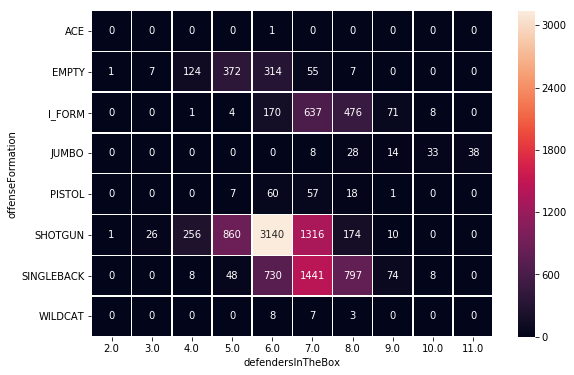

In [48]:
f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(crosstab, annot=True, fmt="d", linewidths=.5, ax=ax);

In [49]:
sum_tracking=tracking.groupby('displayName').aggregate(np.sum).sort_values(by=['dis'], ascending=False)
sum_tracking

,x,y,s,dis,dir,nflId,jerseyNumber,frame.id,gameId,playId
displayName,,,,,,,,,,
football,914599.42,396680.92,74419.81,7950.02,0.00,0.000000e+00,0.0,578731,27720877490100,34515462
Daniel Sorensen,428989.84,179195.23,21987.99,2317.42,1178117.28,1.630889e+10,313355.0,285748,12899295026500,17091130
Jordan Richards,417847.45,176791.89,20695.24,2163.50,1130466.83,1.566148e+10,227032.0,283982,12376868535200,15896747
Devin McCourty,384665.25,160133.32,16526.47,1746.03,1067604.40,2.837207e+09,183680.0,237222,11578100618000,14426466
Kyle Van Noy,428935.67,170370.82,16207.09,1732.15,1148448.05,1.603802e+10,334165.0,277046,12717756863500,16985874
Chris Hogan,298580.44,131728.77,16185.54,1675.65,893209.64,1.276645e+10,75675.0,197088,10176222581500,11525458
Albert Wilson,329064.98,126411.23,16020.67,1661.56,892444.70,1.168535e+10,54984.0,211727,9242309587400,11803995
Phillip Gaines,289277.46,125222.25,15492.28,1614.73,846356.05,1.154400e+10,104374.0,190171,9153557596600,11834178
Stephon Gilmore,381112.14,154768.06,15265.69,1600.96,1036811.87,1.443339e+10,136752.0,236826,11493382808600,14608230


In [55]:
tracking_distance = pd.DataFrame(sum_tracking['dis'])
tracking_distance = tracking_distance.reset_index().head(21)
tracking_distance = tracking_distance.drop([0])
tracking_distance


,displayName,dis
1,Daniel Sorensen,2317.42
2,Jordan Richards,2163.50
3,Devin McCourty,1746.03
4,Kyle Van Noy,1732.15
5,Chris Hogan,1675.65
6,Albert Wilson,1661.56
7,Phillip Gaines,1614.73
8,Stephon Gilmore,1600.96
9,Chris Conley,1586.61
10,Eric Murray,1583.91


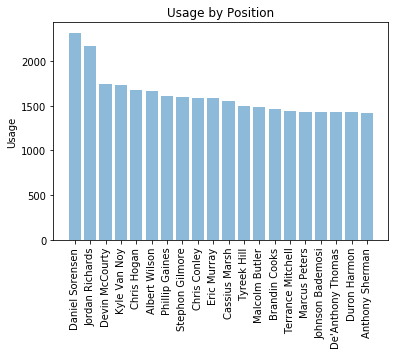

In [58]:


objects2 = tracking_distance['displayName']
y_pos2 = np.arange(len(objects2))
performance2 = tracking_distance['dis']
 
plt.bar(y_pos2, performance2, align='center', alpha=0.5)
plt.xticks(y_pos, objects2)
plt.ylabel('Usage')
plt.title('Usage by Position')
plt.xticks(rotation='vertical')

 
plt.show()